In [1]:
# Environment Variables

import os
import sys

sys.path.append(os.path.abspath(".."))

YES = 1
NO = 0

using_GPU = NO
BACKEND = "Vivado"

In [2]:
# Imports

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import hls4ml
import tensorflow as tf
from qkeras import QConv2DBatchnorm, QActivation, QDense
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
# import src.utils as utils     #! currently does not work
from qkeras.utils import _add_supported_quantized_objects

%matplotlib inline
if using_GPU:
    print(tf.config.list_physical_devices("GPU"))

2026-08-11 01:04:29.789969: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-11 01:04:29.917450: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-08-11 01:04:29.917472: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-08-11 01:04:30.553701: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2026-

In [3]:
# Global Constants

DATA_DIR = "data/"
SRC_DIR = "src/"

RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

IMAGE_X_DIM = 48
IMAGE_Y_DIM = 48

CENTER_X = IMAGE_X_DIM // 2
MIN_CENTER_X = -5
MAX_CENTER_X = 5

CENTER_Y = IMAGE_Y_DIM // 2
MIN_CENTER_Y = -5
MAX_CENTER_Y = 5

MIN_STD_X = 5
MAX_STD_X = 15

MIN_STD_Y = 5
MAX_STD_Y = 15

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.05
MAX_INTENSITY = 0.7

scaling_arr = tf.constant([IMAGE_X_DIM, IMAGE_Y_DIM, IMAGE_X_DIM // 2, IMAGE_X_DIM // 2, MAX_THETA / 2])

2026-08-11 01:04:31.590797: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-08-11 01:04:31.590832: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-08-11 01:04:31.590856: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (hvm1): /proc/driver/nvidia/version does not exist
2026-08-11 01:04:31.591155: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Util Functions

def gaussian_gen(
    center_x: int, center_y: int, std_x: int, std_y: int, theta: float
) -> np.ndarray:
    X = np.arange(0, IMAGE_X_DIM, 1)
    Y = np.arange(0, IMAGE_Y_DIM, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.power(np.cos(theta), 2)
    sin_theta_sqrd = np.power(np.sin(theta), 2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(
        -(
            a * (X - center_x) ** 2
            + 2 * b * (X - center_x) * (Y - center_y)
            + c * (Y - center_y) ** 2
        )
    )

    return np.expand_dims(gaussian, -1)


def gaussian_img_gen(VERBOSE: bool = False) -> tuple:
    # Randomize params
    center_x = CENTER_X + np.random.randint(low=MIN_CENTER_X, high=MAX_CENTER_X)
    center_y = CENTER_Y + np.random.randint(low=MIN_CENTER_Y, high=MAX_CENTER_Y)

    std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
    std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
    theta = np.random.uniform(low=MIN_THETA, high=MAX_THETA)

    intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)

    # Generate Gaussian
    params = (center_x, center_y, std_x, std_y, theta)
    gaussian = gaussian_gen(center_x, center_y, std_x, std_y, theta) * intensity

    # Convert to 8 bit int
    img = gaussian
    # img = (gaussian * 255)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        pass
    return (img, params)

In [5]:
# Functions: (TENSORFLOW)

# mean_x, mean_y, cov_x, cov_y, theta
def generate_guassian(batch, image_shape):
    batch_size = batch.shape[0]
    batch = tf.expand_dims(tf.expand_dims(batch, axis=-1), axis=-1)
    x0, y0, sigma_x, sigma_y, theta = tf.cast(tf.unstack(batch, axis=-3), tf.float32)

    x_range = tf.range(start=0, limit=image_shape[0], delta=1)
    y_range = tf.range(start=0, limit=image_shape[1], delta=1)
    X_coord, Y_coord = tf.meshgrid(x_range, y_range, indexing="xy")
    X_coord = tf.cast(tf.expand_dims(X_coord, axis=0), tf.float32)
    Y_coord = tf.cast(tf.expand_dims(Y_coord, axis=0), tf.float32)

    X_coord = tf.tile(X_coord, [batch_size, 1, 1])
    Y_coord = tf.tile(Y_coord, [batch_size, 1, 1])

    a = tf.math.pow(tf.math.cos(theta), 2) / (
        2 * tf.math.pow(sigma_x, 2)
    ) + tf.math.pow(tf.math.sin(theta), 2) / (2 * tf.math.pow(sigma_y, 2))
    b = -1 * tf.math.sin(theta) * tf.math.cos(theta) / (
        2 * tf.math.pow(sigma_x, 2)
    ) + tf.math.sin(theta) * tf.math.cos(theta) / (2 * tf.math.pow(sigma_y, 2))
    c = tf.math.pow(tf.math.sin(theta), 2) / (
        2 * tf.math.pow(sigma_x, 2)
    ) + tf.math.pow(tf.math.cos(theta), 2) / (2 * tf.math.pow(sigma_y, 2))

    img = tf.exp(
        -1
        * (
            a * (X_coord - x0) ** 2
            + 2 * b * (X_coord - x0) * (Y_coord - y0)
            + c * (Y_coord - y0) ** 2
        )
    )

    if using_GPU:
        return tf.expand_dims(img, axis=-1)  # if (batch_size, height, width, channels)
    
    return tf.expand_dims(img, axis=1)  # if (batch_size, channels, height, width)

def pp_weighted_mse_loss(I, J, n): # TODO: replace I, J, n names
    W = tf.pow(I, n)

    squared_diffs = tf.pow(I - J, 2)

    weighted_squared_diffs = W * squared_diffs

    loss = tf.reduce_mean(weighted_squared_diffs)

    return loss

def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

In [6]:
# Generate Data
SAMPLES_TO_CREATE = 1000


def process_image():
    (
        img,
        label,
    ) = gaussian_img_gen()
    return img, label


img_arr = []
label_arr = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLES_TO_CREATE)]
    for future in tqdm(as_completed(futures), total=SAMPLES_TO_CREATE):
        img, label = future.result()
        img_arr.append(
            # np.round(img / (np.max(img) - 1) * 256) / 256
            np.round(img / (np.max(img)) * 255) / 256
        )  # Normalize values to [0, 1)
        label_arr.append(label)

img_arr = np.array(img_arr)
label_arr = np.array(label_arr)

if using_GPU:
    img_arr = img_arr.reshape(SAMPLES_TO_CREATE, 1, IMAGE_Y_DIM, IMAGE_X_DIM)

print(f"[Images Shape]: {img_arr.shape}")
print(f"[Labels Shape]: {label_arr.shape}")

  9%|▉         | 94/1000 [00:00<00:00, 939.40it/s]

100%|██████████| 1000/1000 [00:00<00:00, 2500.10it/s]


[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 5)


In [7]:
# Convert Data to tf DataSet
BATCH_SIZE = 50

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLES_TO_CREATE, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

In [8]:
# Model Architecture
TOTAL_BITS        = 8
INTEGER_FIRST     = 0   
INTEGER_REST      = 2  
L1_REG            = 1e-4

model = tf.keras.Sequential(
    [
        QConv2DBatchnorm(
            input_shape=(IMAGE_Y_DIM, IMAGE_X_DIM, 1),
            filters=6, kernel_size=3, strides=1, padding="valid",
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{0},alpha=1)",
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{0},alpha=1)",
            kernel_initializer="lecun_uniform",
            kernel_regularizer=tf.keras.regularizers.l1(L1_REG),
            use_bias=True,
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"),
            tf.keras.layers.MaxPool2D(pool_size=4, strides=4
        ),

        QConv2DBatchnorm(
            filters=8, kernel_size=3, strides=1, padding="valid",
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            kernel_initializer="lecun_uniform",
            kernel_regularizer=tf.keras.regularizers.l1(L1_REG),
            use_bias=True,
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"),
            tf.keras.layers.MaxPool2D(pool_size=2, strides=2
        ),

        QConv2DBatchnorm(
            filters=10, kernel_size=3, strides=1, padding="valid",
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            kernel_initializer="lecun_uniform",
            kernel_regularizer=tf.keras.regularizers.l1(L1_REG),
            use_bias=True,
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"),
            tf.keras.layers.MaxPool2D(pool_size=2, strides=2
        ),

        tf.keras.layers.Flatten(),

        QDense(units=15, 
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)", 
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)"
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"
        ),

        QDense(
            units=10, 
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)", 
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)"
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"
        ),

        QDense(units=5 , 
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)", 
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)"
        ),
    ],
    name="pp_model"
)

model.compile(optimizer="adam", loss=dice_loss, run_eagerly=True)
model.summary()

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
Model: "pp_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 q_conv2d_batchnorm (QConv2D  (None, 46, 46, 6)        85        
 Batchnorm)                                                      
                                                                 
 q_activation (QActivation)  (None, 46, 46, 6)         0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 6)        0         
 )                                                               
                                                                 
 q_conv2d_batchnorm_1 (QConv  (None, 9, 9, 8)          473       
 2DBatchnorm)                                          

In [10]:
# Training Loop 
#! TF DType 8bit throughout?
TRAIN_MODEL = NO
SAVE_MODEL = NO
LOAD_MODEL = NO
NUM_EPOCHS = 200
MODEL_PATH = "../Models/"
MODEL_NAME = "gaussian_11_24"


if TRAIN_MODEL:

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.01,
        decay_steps=NUM_EPOCHS,
        decay_rate=0.9)
    
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
        
    loss_arr = []
    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0

        for batch in tqdm(dataset): 
            image_batch = tf.cast(batch[0], tf.float32)
            label_batch = tf.cast(batch[1], tf.float32)
            with tf.GradientTape() as tape:
                embedding = model(image_batch) * scaling_arr

                loss = dice_loss(label_batch, embedding)
            grads = tape.gradient(loss, model.trainable_variables)
            adam_optimizer.apply_gradients(zip(grads, model.trainable_variables))

            running_loss += loss.numpy()
        average_loss = running_loss / len(dataset)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {average_loss}")
        loss_arr.append(average_loss)
    loss_arr = np.array(loss_arr)

co = {}
_add_supported_quantized_objects(co)
# Add any custom losses
co["dice_loss"] = dice_loss

if SAVE_MODEL:
    model.save(f'{MODEL_PATH}{MODEL_NAME}')

if LOAD_MODEL:
    model = tf.keras.models.load_model(f'{MODEL_PATH}{MODEL_NAME}', custom_objects=co)

# model.summary()

In [11]:
validation_gaussian_image = []
validation_gaussian_label = []
for i in range(BATCH_SIZE):
    img, label = gaussian_img_gen()
    img = np.round(img / (np.max(img)) * 255) / 256
    validation_gaussian_image.append(img)
    validation_gaussian_label.append(label)
 
predicted_params = model.predict(tf.cast(validation_gaussian_image, tf.float32)) * scaling_arr
reconstructed_images = generate_guassian(predicted_params, (48,48))

1/2 [==============>...............] - ETA: 0s

2/2 [==============================] - 0s 39ms/step


(24, 23, 9, 6, 1.3029177417623952)
tf.Tensor([25.476562  23.835938   5.6484375  5.6132812  1.1919031], shape=(5,), dtype=float32)


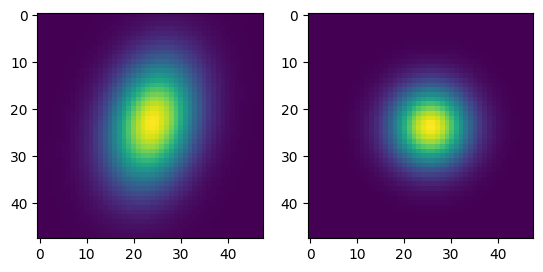

In [12]:
# View (MSE / MAE is not great because fitting is not great)
index = np.random.randint(low=0, high=BATCH_SIZE)

plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(validation_gaussian_image[index]))

plt.subplot(1, 2, 2)
plt.imshow(np.squeeze(reconstructed_images[index]))

print(validation_gaussian_label[index])
print(predicted_params[index])

In [13]:
config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name',
    # backend='Vitis', # new version of hls4ml doesn't use backend arument in config_from keras_model
                       # instead it uses the backend argument in the convert_from_keras_model function
    default_precision='fixed<32,16>',
    default_reuse_factor=32,
)

config['Model']['Strategy'] = 'Resource'
config['Model']['ReuseFactor'] = 16
config['Model']['Precision'] = 'ap_fixed<16,6>'  # 16,6
config['IOType'] = 'io_stream'  


config['LayerName'] = {
    # --- Input ---
    'q_conv2d_batchnorm_input': {
        'Precision': {'result': 'ap_ufixed<8,0>'}  # mono8 input
    },

    # --- Block 1 ---
    'q_conv2d_batchnorm': {
        'Precision': {
            'weight': 'ap_fixed<8,0>', 
            'bias':   'ap_fixed<8,0>',
            'result': 'ap_fixed<8,2>'
        },
        'ReuseFactor': 9,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT'
    },
    'q_activation': {
        'Precision': {'result': 'ap_ufixed<8,2>'},  
        'ReuseFactor': 8
    },
    'max_pooling2d': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 1
    },

    # --- Block 2 ---
    'q_conv2d_batchnorm_1': {
        'Precision': {
            'weight': 'ap_fixed<8,2>',
            'bias':   'ap_fixed<8,2>',
            'result': 'ap_fixed<8,2>'
        },
        'ReuseFactor': 9,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT'
    },
    'q_activation_1': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 8
    },
    'max_pooling2d_1': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 1
    },

    # --- Block 3 ---
    'q_conv2d_batchnorm_2': {
        'Precision': {
            'weight': 'ap_fixed<8,2>',
            'bias':   'ap_fixed<8,2>',
            'result': 'ap_fixed<8,2>'
        },
        'ReuseFactor': 8,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT'
    },
    'q_activation_2': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 8
    },
    'max_pooling2d_2': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 1
    },

    # --- Flatten ---
    'flatten': {
        'Precision': {'result': 'ap_ufixed<8,2>'}
    },

    # --- Dense 15 ---
    'q_dense': {
        'Precision': {
            'weight': 'ap_fixed<8,2>',
            'bias':   'ap_fixed<8,2>',
            'result': 'ap_fixed<8,2>'
        },
        'ReuseFactor': 10,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT'
    },
    'q_activation_3': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 16
    },

    # --- Dense 10 ---
    'q_dense_1': {
        'Precision': {
            'weight': 'ap_fixed<8,2>',
            'bias':   'ap_fixed<8,2>',
            'result': 'ap_fixed<8,2>'
        },
        'ReuseFactor': 15,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT'
    },
    'q_activation_4': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 16
    },

    # --- Dense 5 ---
    'q_dense_2': {
        'Precision': {
            'weight': 'ap_fixed<8,2>',
            'bias':   'ap_fixed<8,2>',
            'result': 'ap_fixed<8,2>'   
        },
        'ReuseFactor': 10,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT'
    },
}


In [14]:
if BACKEND=="Vivado":
    output_dir = f"../hls4ml/gaussian_new_hls4ml_prj"
elif BACKEND=="Vitis":
    output_dir = f"../hls4ml/gaussian_new_hls4ml_prj"
else: raise NotImplementedError
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config, 
    output_dir=output_dir, 
    backend=BACKEND,
    part='xcku035-fbva676-2-e', 
    io_type="io_stream"
)
#  xc7vx690tffg1761-2
# 'xcku035-fbva676-2-e' # original

hls_model.compile() # hls_model.write for Windows 

print("")
print(hls_model.config.config['OutputDir'])

KeyboardInterrupt: 

In [ ]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [15]:
validation_gaussian_image = []
validation_gaussian_label = []
for i in range(BATCH_SIZE):
    gen = gaussian_img_gen()
    validation_gaussian_image.append(gen[0])
    validation_gaussian_label.append(gen[1])

predicted_params_keras = model.predict(tf.cast(validation_gaussian_image, tf.float32)) * scaling_arr
predicted_params_hls = hls_model.predict(np.array(validation_gaussian_image, dtype=np.float32)) * scaling_arr
reconstructed_images_keras = generate_guassian(predicted_params_keras, (48,48))
reconstructed_images_hls = generate_guassian(predicted_params_hls, (48,48))

2/2 [==============================] - 0s 38ms/step


Exception: Model not compiled

In [ ]:
# View (MSE / MAE is not great because fitting is not great)
index = np.random.randint(low=0, high=BATCH_SIZE)

plt.subplot(1, 3, 1)
plt.imshow(np.squeeze(validation_gaussian_image[index]))

plt.subplot(1, 3, 2)
plt.imshow(np.squeeze(reconstructed_images_keras[index]))

plt.subplot(1, 3, 3)
plt.imshow(np.squeeze(reconstructed_images_hls[index]))


print(validation_gaussian_label[index])
print(predicted_params_keras[index])
print(predicted_params_hls[index])

In [ ]:
hls_model.config.config

In [ ]:
hls_model.build(csim=False, synth=True, vsynth=True, export=True)